In [33]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns


## Ex 1

In [ ]:
# Khởi tạo mô hình
input_dim = 5  # Số lượng đặc trưng đầu vào
model_dim = 32  # Kích thước của các vector trong Transformer
num_heads = 4  # Số đầu của multi-head attention
num_layers = 2  # Số lớp encoder trong Transformer
output_dim = 1  # Dự đoán là một giá trị duy nhất

In [ ]:
# Xây dựng kiến trúc mô hình Transformer
class TransformerModel(nn.Module):
    def __init__(self, input_dim, d_model, nhead, num_layers, dim_feedforward, dropout):
        super(TransformerModel, self).__init__()
        # Tạo một lớp Linear để nhúng dữ liệu đầu vào có kích thước input_dim thành vector có kích thước d_model
        # Nhúng dữ liệu đầu vào giúp:
        # 1. Chuyển đổi dữ liệu thành không gian vector có chiều cố định d_model phù hợp với kiến trúc Transformer
        # 2. Học được các đặc trưng quan trọng từ dữ liệu thô
        # 3. Tạo ra biểu diễn dày đặc (dense representation) cho dữ liệu đầu vào
        self.input_embedding = nn.Linear(input_dim, d_model)
        # Mã hóa vị trí (Positional Encoding) là cần thiết trong Transformer vì:
        # 1. Transformer không có tính tuần tự như RNN, nên cần thông tin về vị trí của từng phần tử trong chuỗi
        # 2. Giúp mô hình hiểu được thứ tự thời gian và mối quan hệ tương đối giữa các phần tử
        # 3. Cho phép mô hình phân biệt được các phần tử giống nhau nhưng ở vị trí khác nhau
        # 4. Tăng khả năng học các pattern phụ thuộc vào thứ tự thời gian
        self.positional_encoding = nn.Parameter(torch.zeros(1, 5000, d_model))        
        self.transformer = nn.Transformer(
            d_model=d_model, 
            nhead=nhead, 
            num_encoder_layers=num_layers, 
            num_decoder_layers=num_layers,
            dim_feedforward=dim_feedforward, 
            dropout=dropout,
        )
        self.fc_out = nn.Linear(d_model, 1)
    
    def forward(self, src):
        src_emb = self.input_embedding(src) + self.positional_encoding[:, :src.size(1), :]
        src_emb = src_emb.permute(1, 0, 2)  # [seq_len, batch_size, d_model]
        transformer_out = self.transformer(src_emb, src_emb)
        output = self.fc_out(transformer_out[-1, :, :])  # Lấy giá trị cuối
        return output.squeeze(-1)


In [ ]:
import torch
import shap

# Khởi tạo mô hình transformer như bạn đã làm
class TransformerModelWrapper(torch.nn.Module):
    def __init__(self, model):
        super(TransformerModelWrapper, self).__init__()
        self.model = model

    def forward(self, x):
        return self.model(x)

# Khởi tạo lại mô hình Transformer
model = TransformerModel(input_dim, model_dim, num_heads, num_layers, output_dim)

# Đóng gói mô hình vào một lớp Wrapper
model_wrapper = TransformerModelWrapper(model)

# Khởi tạo SHAP explainer với mô hình đã bọc
explainer = shap.Explainer(model_wrapper, train_dataset.X[:100])  # Lấy một mẫu con của dữ liệu để huấn luyện explainer

# Giải thích một dự đoán ngẫu nhiên từ dữ liệu
sample_input, _ = train_dataset[42]  # Chọn mẫu dữ liệu thứ 42
shap_values = explainer(sample_input.unsqueeze(0))  # Thêm một batch dimension

# Trực quan hóa kết quả
shap.plots.waterfall(shap_values[0])  # Vẽ biểu đồ waterfall


e:\IAD\.venv\Lib\site-packages\torch\nn\modules\transformer.py:379: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


TypeError: 'Tensor' object is not callable

In [ ]:
import torch
import shap

# Khởi tạo mô hình transformer như bạn đã làm
class TransformerModelWrapper(torch.nn.Module):
    def __init__(self, model):
        super(TransformerModelWrapper, self).__init__()
        self.model = model

    def forward(self, x):
        return self.model(x)

# Khởi tạo lại mô hình Transformer
model = TransformerModel(input_dim, model_dim, num_heads, num_layers, output_dim)

# Đóng gói mô hình vào một lớp Wrapper
model_wrapper = TransformerModelWrapper(model)

# Khởi tạo SHAP explainer với mô hình đã bọc
explainer = shap.Explainer(model_wrapper, train_dataset.X[:100])  # Lấy một mẫu con của dữ liệu để huấn luyện explainer

# Giải thích một dự đoán ngẫu nhiên từ dữ liệu
sample_input, _ = train_dataset[42]  # Chọn mẫu dữ liệu thứ 42
shap_values = explainer(sample_input.unsqueeze(0))  # Thêm một batch dimension

# Trực quan hóa kết quả
shap.plots.waterfall(shap_values[0])  # Vẽ biểu đồ waterfall


e:\IAD\.venv\Lib\site-packages\torch\nn\modules\transformer.py:379: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


TypeError: 'Tensor' object is not callable

In [ ]:
import torch
import shap

# Khởi tạo mô hình transformer như bạn đã làm
class TransformerModelWrapper(torch.nn.Module):
    def __init__(self, model):
        super(TransformerModelWrapper, self).__init__()
        self.model = model

    def forward(self, x):
        return self.model(x)

# Khởi tạo lại mô hình Transformer
model = TransformerModel(input_dim, model_dim, num_heads, num_layers, output_dim)

# Đóng gói mô hình vào một lớp Wrapper
model_wrapper = TransformerModelWrapper(model)

# Khởi tạo SHAP explainer với mô hình đã bọc
explainer = shap.Explainer(model_wrapper, train_dataset.X[:100])  # Lấy một mẫu con của dữ liệu để huấn luyện explainer

# Giải thích một dự đoán ngẫu nhiên từ dữ liệu
sample_input, _ = train_dataset[42]  # Chọn mẫu dữ liệu thứ 42
shap_values = explainer(sample_input.unsqueeze(0))  # Thêm một batch dimension

# Trực quan hóa kết quả
shap.plots.waterfall(shap_values[0])  # Vẽ biểu đồ waterfall


e:\IAD\.venv\Lib\site-packages\torch\nn\modules\transformer.py:379: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


TypeError: 'Tensor' object is not callable

In [ ]:
import torch
import shap

# Khởi tạo mô hình transformer như bạn đã làm
class TransformerModelWrapper(torch.nn.Module):
    def __init__(self, model):
        super(TransformerModelWrapper, self).__init__()
        self.model = model

    def forward(self, x):
        return self.model(x)

# Khởi tạo lại mô hình Transformer
model = TransformerModel(input_dim, model_dim, num_heads, num_layers, output_dim)

# Đóng gói mô hình vào một lớp Wrapper
model_wrapper = TransformerModelWrapper(model)

# Khởi tạo SHAP explainer với mô hình đã bọc
explainer = shap.Explainer(model_wrapper, train_dataset.X[:100])  # Lấy một mẫu con của dữ liệu để huấn luyện explainer

# Giải thích một dự đoán ngẫu nhiên từ dữ liệu
sample_input, _ = train_dataset[42]  # Chọn mẫu dữ liệu thứ 42
shap_values = explainer(sample_input.unsqueeze(0))  # Thêm một batch dimension

# Trực quan hóa kết quả
shap.plots.waterfall(shap_values[0])  # Vẽ biểu đồ waterfall


e:\IAD\.venv\Lib\site-packages\torch\nn\modules\transformer.py:379: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


TypeError: 'Tensor' object is not callable

In [35]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns

# Tùy chỉnh MultiheadAttention để lưu trữ ma trận attention
class CustomMultiheadAttention(nn.MultiheadAttention):
    def forward(self, query, key, value, **kwargs):
        attn_output, attn_weights = super().forward(query, key, value, **kwargs)
        # Lưu ma trận attention weights để truy cập sau
        self.attn_weights = attn_weights
        return attn_output

# Tùy chỉnh TransformerEncoderLayer
class CustomTransformerEncoderLayer(nn.TransformerEncoderLayer):
    def __init__(self, d_model, nhead, dim_feedforward=2048, dropout=0.1):
        super().__init__(d_model, nhead, dim_feedforward, dropout)
        self.self_attn = CustomMultiheadAttention(d_model, nhead, dropout=dropout)

    def forward(self, src, src_mask=None, src_key_padding_mask=None, is_causal=None):
        # Bỏ qua is_causal vì không ảnh hưởng trong logic này
        src2 = self.self_attn(src, src, src, attn_mask=src_mask, key_padding_mask=src_key_padding_mask)
        src = src + self.dropout1(src2)
        src = self.norm1(src)
        src2 = self.linear2(self.dropout(self.activation(self.linear1(src))))
        src = src + self.dropout2(src2)
        src = self.norm2(src)
        return src

# Tùy chỉnh Transformer để lấy attention
class TransformerWithAttention(nn.Module):
    def __init__(self, input_dim, d_model, nhead, num_layers, dim_feedforward, dropout):
        super().__init__()
        self.input_embedding = nn.Linear(input_dim, d_model)
        self.positional_encoding = nn.Parameter(torch.zeros(1, 5000, d_model))
        
        encoder_layer = CustomTransformerEncoderLayer(
            d_model=d_model, 
            nhead=nhead, 
            dim_feedforward=dim_feedforward, 
            dropout=dropout
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers)
        self.fc_out = nn.Linear(d_model, 1)

    def forward_with_attention(self, src):
        src_emb = self.input_embedding(src) + self.positional_encoding[:, :src.size(1), :]
        src_emb = src_emb.permute(1, 0, 2)  # [seq_len, batch_size, d_model]

        # Forward qua Transformer Encoder
        encoder_output = self.transformer_encoder(src_emb)

        # Lấy attention weights từ lớp đầu tiên
        attn_weights = self.transformer_encoder.layers[0].self_attn.attn_weights
        output = self.fc_out(encoder_output[-1, :, :])  # Lấy giá trị cuối
        return output.squeeze(-1), attn_weights

# Kiểm tra mô hình
input_dim = 10
seq_len = 20
batch_size = 1
model = TransformerWithAttention(
    input_dim=input_dim, 
    d_model=64, 
    nhead=4, 
    num_layers=2, 
    dim_feedforward=128, 
    dropout=0.1
)

src = torch.rand(batch_size, seq_len, input_dim)

model.eval()
with torch.no_grad():
    output, attn_weights = model.forward_with_attention(src)

# Kiểm tra lại attention weights
if attn_weights is None:
    raise ValueError("Attention weights không được lưu. Kiểm tra logic của CustomMultiheadAttention!")

e:\IAD\.venv\Lib\site-packages\torch\nn\modules\transformer.py:379: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


***Ý Nghĩa Biểu Đồ Attention***
- Trục hoành (Input Sequence): Đại diện cho các bước thời gian trong chuỗi đầu vào của bạn. Mỗi giá trị trên trục này biểu thị một đặc trưng đầu vào tại thời điểm cụ thể.
- Trục tung (Input Sequence): Đại diện cho các bước thời gian được chú ý bởi bước thời gian tương ứng trên trục hoành.
- Màu sắc: Trọng số attention (giá trị từ self-attention mechanism) giữa các bước thời gian. Giá trị càng sáng thì mức độ quan trọng giữa các bước thời gian càng cao.

***Để Giải Thích Biểu Đồ:***

****Ý tưởng chính của attention:****

Mô hình đang "chú ý" đến các bước thời gian khác nhau trong chuỗi để đưa ra dự đoán.
Trọng số attention cho biết mức độ liên quan giữa một bước thời gian và những bước thời gian khác.
Giải thích ví dụ:

Trong biểu đồ của bạn, nếu ô (10, 12) có giá trị sáng, điều này có nghĩa là bước thời gian thứ 10 trong chuỗi đầu vào rất chú ý đến bước thời gian thứ 12 khi ra quyết định.
Ý nghĩa với dữ liệu CMAPSS:

Chuỗi đầu vào của bạn là dữ liệu sensor readings qua các chu kỳ.
Trọng số attention có thể giải thích rằng ở các chu kỳ cụ thể, mô hình tập trung vào các bước thời gian (chu kỳ) trước đó để dự đoán Remaining Useful Life (RUL).



Shape of attention weights: torch.Size([1, 20, 20])
Head 0


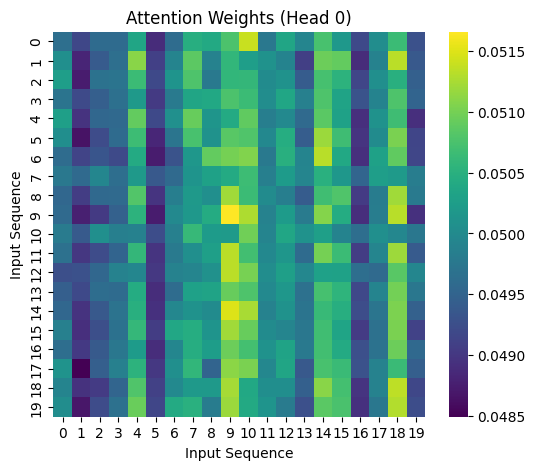

In [36]:
# Kiểm tra kích thước của attn_weights để đảm bảo có nhiều head
print(f"Shape of attention weights: {attn_weights.shape}")

# Nếu attn_weights có nhiều head, bạn có thể lặp qua các head
# Giả sử attn_weights có dạng [nhead, seq_len, seq_len]
nheads = attn_weights.shape[0]

# Lặp qua từng head và vẽ heatmap
for head_idx in range(min(3, nheads)):  # Lặp qua số lượng head có sẵn, giới hạn tối đa là 3
    attn_weights_head = attn_weights[head_idx].detach().numpy()  # Chọn head cụ thể
    print(f'Head {head_idx}')
    plt.figure(figsize=(6, 5))
    ax = sns.heatmap(attn_weights_head, cmap="viridis")
    ax.set_title(f"Attention Weights (Head {head_idx})")
    ax.set_xlabel("Input Sequence")
    ax.set_ylabel("Input Sequence")
    plt.show()


In [37]:
print(f"Shape of attention weights: {attn_weights.shape}")

Shape of attention weights: torch.Size([1, 20, 20])


## Ex 2

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import shap
import numpy as np
import matplotlib.pyplot as plt

# Định nghĩa mô hình Transformer đơn giản
class TransformerModel(nn.Module):
    def __init__(self, input_dim, model_dim, num_heads, num_layers, output_dim):
        super(TransformerModel, self).__init__()
        self.embedding = nn.Linear(input_dim, model_dim)
        self.transformer = nn.Transformer(d_model=model_dim, nhead=num_heads, num_encoder_layers=num_layers)
        self.fc = nn.Linear(model_dim, output_dim)

    def forward(self, x):
        x = self.embedding(x)  # Áp dụng lớp embedding
        x = x.permute(1, 0, 2)  # Cần chuyển đổi để phù hợp với mô hình Transformer (seq_len, batch_size, feature)
        output = self.transformer(x, x)  # Chạy qua mô hình Transformer
        output = output.mean(dim=0)  # Pooling qua các thời điểm (sequence)
        output = self.fc(output)  # Dự đoán cuối cùng
        return output

# Khởi tạo mô hình
input_dim = 5  # Số lượng đặc trưng đầu vào
model_dim = 32  # Kích thước của các vector trong Transformer
num_heads = 4  # Số đầu của multi-head attention
num_layers = 2  # Số lớp encoder trong Transformer
output_dim = 1  # Dự đoán là một giá trị duy nhất

model = TransformerModel(input_dim, model_dim, num_heads, num_layers, output_dim)


e:\IAD\.venv\Lib\site-packages\torch\nn\modules\transformer.py:379: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


In [2]:
from torch.utils.data import Dataset, DataLoader

# Tạo dữ liệu giả lập
class TimeSeriesDataset(Dataset):
    def __init__(self, n_samples=1000, seq_len=50, input_dim=5):
        self.n_samples = n_samples
        self.seq_len = seq_len
        self.input_dim = input_dim
        
        # Tạo dữ liệu ngẫu nhiên
        self.X = torch.randn(n_samples, seq_len, input_dim)
        self.y = torch.sum(self.X, dim=[1, 2])  # Cộng tất cả các giá trị trong chuỗi để làm nhãn

    def __len__(self):
        return self.n_samples

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# Tạo dataset và dataloader
train_dataset = TimeSeriesDataset(n_samples=1000)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
    

In [3]:
# Huấn luyện mô hình
def train_model(model, dataloader, epochs=5, lr=0.001):
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()  # Dùng loss hàm MSE vì đây là bài toán hồi quy

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for inputs, labels in dataloader:
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels.unsqueeze(1))  # Chuyển labels thành (batch_size, 1)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {running_loss/len(dataloader)}")

train_model(model, train_loader)


Epoch [1/5], Loss: 247.10577869415283
Epoch [2/5], Loss: 185.20279097557068
Epoch [3/5], Loss: 153.78518950939178
Epoch [4/5], Loss: 132.48066401481628
Epoch [5/5], Loss: 110.03438150882721


In [32]:
sample_input = np.random.rand(50, 14)
print(sample_input.shape)
print(sample_input)

(50, 14)
[[2.79420954e-01 1.95001317e-03 6.72970873e-01 2.63776530e-01
  3.40942291e-01 6.83289613e-01 7.54598576e-01 9.01999594e-01
  6.96717717e-01 2.76876228e-01 6.03634241e-01 8.20387602e-01
  6.61392760e-01 6.18114122e-02]
 [2.22890870e-01 1.65051799e-01 4.81668164e-01 3.76967684e-01
  3.41553158e-01 5.57371025e-01 2.42565445e-01 6.12920370e-01
  9.43385491e-01 6.60082119e-01 5.40143393e-01 3.75240302e-01
  8.53233519e-01 4.07351315e-01]
 [7.46333024e-01 8.97659919e-01 6.35215832e-01 6.93937185e-01
  5.33441849e-01 3.94206976e-02 3.34960890e-01 1.68684345e-01
  5.27450551e-01 9.17437405e-01 2.07867084e-01 2.56158044e-01
  2.56781365e-01 3.25275055e-01]
 [9.58673688e-01 1.28850111e-01 2.87849690e-01 3.39533517e-01
  7.51829547e-01 5.37423267e-01 8.33392302e-01 2.06597232e-01
  5.45180173e-01 4.91210419e-01 1.26188653e-01 4.60534714e-01
  5.17382469e-01 1.19085616e-01]
 [4.79587157e-01 8.54150840e-01 3.66231171e-01 5.65637085e-01
  4.82317185e-01 2.30649763e-01 1.30137937e-01 9.4943

In [35]:
import torch
import torch.nn as nn
import shap
import numpy as np
import matplotlib.pyplot as plt

# Giả sử bạn đã có một mô hình PyTorch
class SimpleModel(torch.nn.Module):
    def __init__(self):
        super(SimpleModel, self).__init__()
        self.fc = torch.nn.Linear(50, 14)  # 5 đặc trưng đầu vào, 1 giá trị dự đoán đầu ra
    def forward(self, x):
        return self.fc(x)

# Wrapper cho mô hình
class ModelWrapper:
    def __init__(self, model):
        self.model = model

    def __call__(self, X):
        # Đảm bảo rằng đầu vào là tensor
        X = torch.tensor(X, dtype=torch.float32)
        return self.model(X)

In [39]:
# Giả sử dữ liệu đầu vào là numpy.ndarray
# sample_input = np.random.rand(1, size=(50, 14))
sample_input = sample_input.reshape(1, 50, 14)
sample_input.shape

(1, 50, 14)

In [40]:
# Khởi tạo mô hình và wrapper
model = SimpleModel()
input_dim = 5  # Số lượng đặc trưng đầu vào
model_dim = 32  # Kích thước của các vector trong Transformer
num_heads = 4  # Số đầu của multi-head attention
num_layers = 2  # Số lớp encoder trong Transformer
output_dim = 1  # Dự đoán là một giá trị duy nhất

# X = np.random.rand(100, 50, input_dim).astype(np.float32)  # Dữ liệu đặc trưng dạng sequence
# y = np.random.rand(100, output_dim).astype(np.float32)  # Nhãn tương ứng (ví dụ bài toán hồi quy)


# model = TransformerModel(input_dim, model_dim, num_heads, num_layers, output_dim)
model_wrapper = ModelWrapper(model)

# Khởi tạo explainer với dữ liệu mẫu và wrapper mô hình
explainer = shap.Explainer(model_wrapper, sample_input)

# Chọn một ví dụ để giải thích
# sample_input = np.random.rand(1, 50)  # Chọn một mẫu dữ liệu mới

# Giải thích một dự đoán
shap_values = explainer(sample_input)

# Trực quan hóa kết quả
shap.plots.waterfall(shap_values[0])  # Vẽ biểu đồ waterfall


TypeError: 'numpy.ndarray' object is not callable

In [31]:
sample_input.shape

(1, 50)

In [ ]:
# Khởi tạo mô hình và wrapper
model = SimpleModel()
input_dim = 5  # Số lượng đặc trưng đầu vào
model_dim = 32  # Kích thước của các vector trong Transformer
num_heads = 4  # Số đầu của multi-head attention
num_layers = 2  # Số lớp encoder trong Transformer
output_dim = 1  # Dự đoán là một giá trị duy nhất

# X = np.random.rand(100, 50, input_dim).astype(np.float32)  # Dữ liệu đặc trưng dạng sequence
# y = np.random.rand(100, output_dim).astype(np.float32)  # Nhãn tương ứng (ví dụ bài toán hồi quy)


# model = TransformerModel(input_dim, model_dim, num_heads, num_layers, output_dim)
model_wrapper = ModelWrapper(model)

# Khởi tạo explainer với dữ liệu mẫu và wrapper mô hình
explainer = shap.Explainer(model_wrapper, sample_input)

# Chọn một ví dụ để giải thích
sample_input = np.random.rand(1, 50)  # Chọn một mẫu dữ liệu mới

# Giải thích một dự đoán
shap_values = explainer(sample_input)

# Trực quan hóa kết quả
shap.plots.waterfall(shap_values[0])  # Vẽ biểu đồ waterfall
